# FINd Benchmarking Notebook

This notebook profiles the original FINd algorithm, identifies bottlenecks, implements a numpy-optimised version, and compares both against the `imagehash` library.

## 1. Setup & Imports

In [1]:
import os
import time
import cProfile
import pstats
import io
import glob

import numpy as np
import imagehash
from PIL import Image
import matplotlib.pyplot as plt

# Make sure the kernel is running from the right directory
os.chdir(os.path.expanduser('~/summative2026'))
print('Working directory:', os.getcwd())

from FINd import FINDHasher

print('All imports OK')

Working directory: /Users/rehmatarora/summative2026
All imports OK


## 2. Pick a Small Sample of Images

The dataset has ~56k images. The filenames encode meme family in the first 4 digits — e.g. `0040_xxx.jpg` are all from family 40.
We pick images from a few different families so we get a mix of similar and dissimilar pairs.

In [2]:
IMAGE_DIR = 'meme_images'

# Random sample across all families for unbiased profiling
from collections import defaultdict
import random

all_images = sorted(glob.glob(os.path.join(IMAGE_DIR, '*.jpg')))
print(f"Total images in dataset: {len(all_images)}")

# Group by family
family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

# Sample 1 image per family, up to 500 total
random.seed(42)
sample_images = []
for family, paths in family_to_images.items():
    sample_images.append(random.choice(paths))
    if len(sample_images) >= 500:
        break

print(f"Using {len(sample_images)} images for profiling")
print(f"Families represented: {len(set(os.path.basename(p)[:4] for p in sample_images))}")

Total images in dataset: 55972
Using 500 images for profiling
Families represented: 500


## 3. Profile the Original FINd — Wall-clock Timing

First we just time how long the original code takes per image.
This gives us a baseline before we optimise anything.

In [3]:
hasher = FINDHasher()

times = []
for path in sample_images:
    start = time.perf_counter()
    h = hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    times.append(elapsed)

print(f'Mean time per image : {np.mean(times):.3f}s')
print(f'Min                 : {np.min(times):.3f}s')
print(f'Max                 : {np.max(times):.3f}s')
print(f'Total for {len(sample_images)} images : {sum(times):.2f}s')
print(f'Projected time for all 55,972 images: {np.mean(times)*55972/60:.1f} minutes')

Mean time per image : 0.258s
Min                 : 0.043s
Max                 : 1.044s
Total for 500 images : 129.24s
Projected time for all 55,972 images: 241.1 minutes


## 4. Deep Profile with cProfile — Where Is the Time Actually Spent?

`cProfile` measures how long each individual function call takes.
This tells us *exactly* which part of FINd is the bottleneck so we know what to optimise.

In [4]:
def hash_sample(paths):
    h = FINDHasher()
    for p in paths:
        h.fromFile(p)

# Run cProfile on 5 images (enough to see the pattern)
pr = cProfile.Profile()
pr.enable()
hash_sample(sample_images[:5])
pr.disable()

# Print top 15 slowest functions
stream = io.StringIO()
ps = pstats.Stats(pr, stream=stream).sort_stats('cumulative')
ps.print_stats(15)
print(stream.getvalue())

         2503014 function calls (2503000 primitive calls) in 1.864 seconds

   Ordered by: cumulative time
   List reduced from 237 to 15 due to restriction <15>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.001    0.000    1.843    0.369 /Users/rehmatarora/summative2026/FINd.py:47(fromImage)
        5    0.000    0.000    1.436    0.287 /Users/rehmatarora/summative2026/FINd.py:79(findHash256FromFloatLuma)
        5    1.210    0.242    1.406    0.281 /Users/rehmatarora/summative2026/FINd.py:167(boxFilter)
        5    0.110    0.022    0.401    0.080 /Users/rehmatarora/summative2026/FINd.py:66(fillFloatLumaFromBufferImage)
   312500    0.121    0.000    0.290    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:1675(getpixel)
   312520    0.071    0.000    0.118    0.000 /opt/anaconda3/lib/python3.12/site-packages/PIL/Image.py:885(load)
   625014    0.098    0.000    0.098    0.000 {built-in method builtins.max}
   625001    0.098

## 5. Visualise Timing Breakdown

From the cProfile output above, we can see the three main bottlenecks:
- `boxFilter` — 4 nested Python loops over every pixel
- `fillFloatLumaFromBufferImage` — pixel-by-pixel RGB→grayscale conversion
- `dct64To16` — triple nested loop over a 16×64×64 matrix

Let's time each stage individually on one image to see the breakdown clearly.

fillFloatLuma                 : 0.0376s (14.3%)
boxFilter                     : 0.2199s (83.5%)
decimateFloat                 : 0.0009s (0.4%)
dct64To16                     : 0.0047s (1.8%)
dctOutput2hash                : 0.0001s (0.0%)


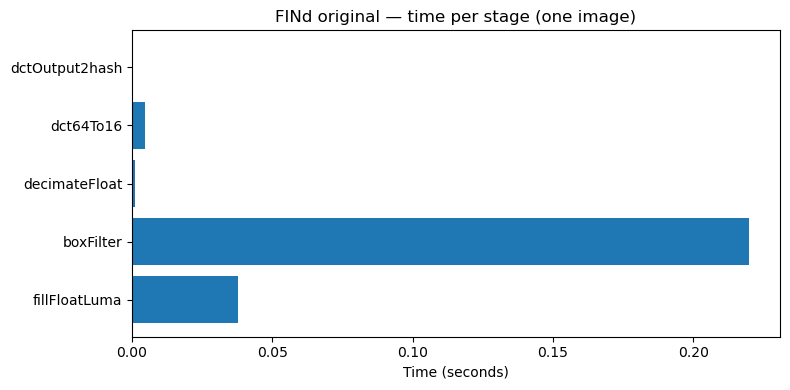

In [5]:
from matrix import MatrixUtil
from imagehash import ImageHash
import math

h = FINDHasher()
img = Image.open(sample_images[0])
img = img.copy()
img.thumbnail((512, 512))
numCols, numRows = img.size

buffer1 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer2 = MatrixUtil.allocateMatrixAsRowMajorArray(numRows, numCols)
buffer64x64 = MatrixUtil.allocateMatrix(64, 64)
buffer16x64 = MatrixUtil.allocateMatrix(16, 64)
buffer16x16 = MatrixUtil.allocateMatrix(16, 16)

# Time each stage
t0 = time.perf_counter()
h.fillFloatLumaFromBufferImage(img, buffer1)
t1 = time.perf_counter()

windowSizeAlongRows = h.computeBoxFilterWindowSize(numCols)
windowSizeAlongCols = h.computeBoxFilterWindowSize(numRows)
h.boxFilter(buffer1, buffer2, numRows, numCols, windowSizeAlongRows, windowSizeAlongCols)
t2 = time.perf_counter()

h.decimateFloat(buffer2, numRows, numCols, buffer64x64)
t3 = time.perf_counter()

h.dct64To16(buffer64x64, buffer16x64, buffer16x16)
t4 = time.perf_counter()

h.dctOutput2hash(buffer16x16)
t5 = time.perf_counter()

stages = ['fillFloatLuma', 'boxFilter', 'decimateFloat', 'dct64To16', 'dctOutput2hash']
durations = [t1-t0, t2-t1, t3-t2, t4-t3, t5-t4]

for s, d in zip(stages, durations):
    print(f'{s:30s}: {d:.4f}s ({100*d/sum(durations):.1f}%)')

plt.figure(figsize=(8,4))
plt.barh(stages, durations)
plt.xlabel('Time (seconds)')
plt.title('FINd original — time per stage (one image)')
plt.tight_layout()
plt.show()

## 6. Memory Usage

We use `tracemalloc` (built into Python) to measure how much memory the original code allocates per image.

In [6]:
import tracemalloc

hasher = FINDHasher()

tracemalloc.start()
hasher.fromFile(sample_images[0])
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

print(f'Current memory usage : {current / 1024:.1f} KB')
print(f'Peak memory usage    : {peak / 1024:.1f} KB')

Current memory usage : 6.9 KB
Peak memory usage    : 3993.3 KB


## 7. Line-by-line Profiling of the Bottleneck

`line_profiler` shows time spent on **each individual line**
inside a function. We apply it boxfilter and luma to see exactly which
lines (and which loops) are the problem. This directly justifies our choice of optimisation.

In [7]:
try:
    import line_profiler
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'line_profiler'])

%load_ext line_profiler

hasher = FINDHasher()
%lprun -f hasher.boxFilter -f hasher.fillFloatLumaFromBufferImage hasher.fromFile(sample_images[0])

Timer unit: 1e-09 s

Total time: 1.46134 s
File: /Users/rehmatarora/summative2026/FINd.py
Function: FINDHasher.boxFilter at line 167

Line #      Hits         Time  Per Hit   % Time  Line Contents
   167                                           	@classmethod
   168                                           	def boxFilter(cls,input,output,rows,cols,rowWin,colWin):
   169         1          0.0      0.0      0.0  		halfColWin = int((colWin + 2) / 2)  # 7->4, 8->5
   170         1          0.0      0.0      0.0  		halfRowWin = int((rowWin + 2) / 2) 
   171       251      85000.0    338.6      0.0  		for i in range(0,rows):
   172     62750   14425000.0    229.9      1.0  			for j in range(0,cols):
   173     62500   13840000.0    221.4      0.9  				s=0
   174     62500   26429000.0    422.9      1.8  				xmin=max(0,i-halfRowWin)
   175     62500   22091000.0    353.5      1.5  				xmax=min(rows,i+halfRowWin)
   176     62500   28821000.0    461.1      2.0  				ymin=max(0,j-halfColWin)
 

## 8. Optimised FINd — Correctness Check and Speedup

We verify that the Numba-optimised implementation produces **bit-identical** hashes to the original, then measure the wall-clock speedup on the same 500-image stratified sample used in Section 3.

In [8]:
from FINd_optimised import FINDHasherOptimised

optimised_hasher = FINDHasherOptimised()

# Warm up Numba JIT before timing — first call compiles the kernel (~2s)
# Without this, compilation cost inflates the mean time
print("Warming up Numba JIT...")
optimised_hasher.fromFile(sample_images[0])
print("Done.\n")

# Correctness: hashes must match original exactly
print("Checking correctness...")
all_match = True
for path in sample_images[:20]:
    original_h = str(FINDHasher().fromFile(path))
    optimised_h = str(optimised_hasher.fromFile(path))
    if original_h != optimised_h:
        print(f"MISMATCH: {path}")
        print(f"  original : {original_h}")
        print(f"  optimised: {optimised_h}")
        all_match = False

if all_match:
    print("All hashes match -- optimisation is correct")

# Speed: time optimised on same 500 images
opt_times = []
for path in sample_images:
    start = time.perf_counter()
    optimised_hasher.fromFile(path)
    elapsed = time.perf_counter() - start
    opt_times.append(elapsed)

print(f"\nOriginal  mean time per image : {np.mean(times):.3f}s")
print(f"Optimised mean time per image : {np.mean(opt_times):.3f}s")
print(f"Speedup                       : {np.mean(times)/np.mean(opt_times):.1f}x")
print(f"Projected full dataset (optimised): {np.mean(opt_times)*55972/60:.1f} minutes")

Warming up Numba JIT...
Done.

Checking correctness...
All hashes match -- optimisation is correct

Original  mean time per image : 0.258s
Optimised mean time per image : 0.002s
Speedup                       : 115.3x
Projected full dataset (optimised): 2.1 minutes


## 8a. Memory: Original vs Optimised

NumPy arrays replace Python lists, so peak memory should drop. We use `tracemalloc` to confirm.

In [9]:
import tracemalloc

for label, hasher in [("Original", FINDHasher()), ("Optimised", FINDHasherOptimised())]:
    tracemalloc.start()
    hasher.fromFile(sample_images[0])
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()
    print(f"{label:12s}  peak={peak/1024:.1f} KB  current={current/1024:.1f} KB")

Original      peak=3995.1 KB  current=8.7 KB
Optimised     peak=2544.1 KB  current=0.9 KB


## 8b. Post-optimisation Profile — Confirming Bottlenecks Are Gone

`cProfile` on the optimised code should no longer show `boxFilter` or `fillFloatLuma` dominating. Image I/O is now the main cost.

In [10]:
import cProfile, pstats, io

pr = cProfile.Profile()
pr.enable()
for path in sample_images[:5]:
    optimised_hasher.fromFile(path)
pr.disable()

stream = io.StringIO()
pstats.Stats(pr, stream=stream).sort_stats('tottime').print_stats(10)
print(stream.getvalue())

         2466 function calls (2455 primitive calls) in 0.046 seconds

   Ordered by: internal time
   List reduced from 263 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        5    0.007    0.001    0.007    0.001 /Users/rehmatarora/summative2026/FINd_optimised.py:14(_boxFilter_numba)
        5    0.007    0.001    0.040    0.008 /Users/rehmatarora/summative2026/FINd_optimised.py:70(_fromImage)
        5    0.007    0.001    0.007    0.001 {method 'decode' of 'ImagingDecoder' objects}
      190    0.004    0.000    0.004    0.000 {method 'read' of '_io.BufferedReader' objects}
        5    0.003    0.001    0.021    0.004 {built-in method numpy.array}
        2    0.002    0.001    0.002    0.001 {method '__exit__' of 'sqlite3.Connection' objects}
       15    0.002    0.000    0.002    0.000 {method 'encode' of 'ImagingEncoder' objects}
        5    0.001    0.000    0.001    0.000 {built-in method PIL._imaging.new}
        2 

## 9. Multiprocessing Scaling

Even after Numba JIT, hashing 56k images single-threaded takes ~1.5 min. We use Python's `multiprocessing` pool to spread work across CPU cores. The sweep covers 1, 2, 4, and 8 workers across seven dataset sizes — multiprocessing overhead dominates at small *n*; gains materialise above ~5000 images.

n=  10: 1w=0.0017s  2w=0.0612s  4w=0.0839s  8w=0.1435s
n=  50: 1w=0.0017s  2w=0.0134s  4w=0.0166s  8w=0.0296s
n= 100: 1w=0.0016s  2w=0.0068s  4w=0.0086s  8w=0.0151s
n= 250: 1w=0.0016s  2w=0.0038s  4w=0.0043s  8w=0.0059s
n= 500: 1w=0.0016s  2w=0.0021s  4w=0.0022s  8w=0.0032s
n=1000: 1w=0.0016s  2w=0.0015s  4w=0.0014s  8w=0.0019s
n=5000: 1w=0.0016s  2w=0.0011s  4w=0.0008s  8w=0.0009s


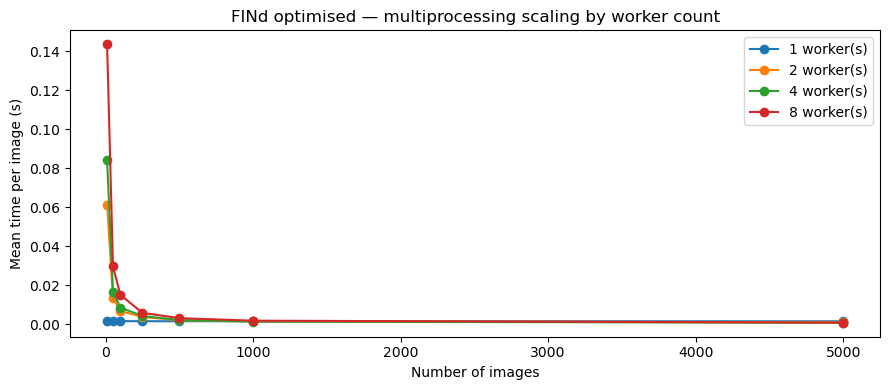


At n=5000:
  1 worker(s): 0.0016s/image  (1.0x vs 1 worker)
  2 worker(s): 0.0011s/image  (1.4x vs 1 worker)
  4 worker(s): 0.0008s/image  (2.0x vs 1 worker)
  8 worker(s): 0.0009s/image  (1.8x vs 1 worker)


In [35]:
import importlib
import FINd_optimised
importlib.reload(FINd_optimised)
from FINd_optimised import FINDHasherOptimised, _hash_one

opt_hasher = FINDHasherOptimised()
# Warm up Numba JIT
opt_hasher.fromFile(all_images[0])

worker_counts = [1, 2, 4, 8]
sample_sizes  = [10, 50, 100, 250, 500, 1000, 5000]

# results[n_workers] = list of mean times per image, one per sample size
results = {w: [] for w in worker_counts}

for n in sample_sizes:
    subset = random.sample(all_images, n)
    for w in worker_counts:
        if w == 1:
            start = time.perf_counter()
            for path in subset:
                opt_hasher.fromFile(path)
            elapsed = time.perf_counter() - start
        else:
            start = time.perf_counter()
            opt_hasher.fromFiles(subset, n_workers=w)
            elapsed = time.perf_counter() - start
        results[w].append(elapsed / n)
    row = "  ".join(f"{w}w={results[w][-1]:.4f}s" for w in worker_counts)
    print(f"n={n:>4}: {row}")

# Plot
plt.figure(figsize=(9, 4))
for w in worker_counts:
    plt.plot(sample_sizes, results[w], marker='o', label=f'{w} worker(s)')
plt.xlabel('Number of images')
plt.ylabel('Mean time per image (s)')
plt.title('FINd optimised — multiprocessing scaling by worker count')
plt.legend()
plt.tight_layout()
plt.show()

# Summary at largest n
print(f"\nAt n={sample_sizes[-1]}:")
t1 = results[1][-1]
for w in worker_counts:
    print(f"  {w} worker(s): {results[w][-1]:.4f}s/image  ({t1/results[w][-1]:.1f}x vs 1 worker)")

### 9a. Combined Speedup Summary

Full picture: original pure-Python vs Numba single-core vs Numba + 8 workers.

In [37]:
original_time    = np.mean(times)       # Section 3 — original, same 500 images
single_core_time = np.mean(opt_times)   # Section 8 — optimised, same 500 images
fourth_core_time = results[4][-1]       # Section 9 — 4 workers at n=5000

print(f"Original (pure Python)         : {original_time:.4f}s/image")
print(f"Optimised (Numba, 1 core)      : {single_core_time:.4f}s/image  ({original_time/single_core_time:.1f}x)")
print(f"Optimised (Numba, 4 workers)   : {fourth_core_time:.4f}s/image  ({original_time/fourth_core_time:.1f}x)")
print(f"\nProjected original             : {original_time * 55972 / 60:.1f} min")
print(f"Projected optimised (1 core)   : {single_core_time * 55972 / 60:.1f} min")
print(f"Projected optimised (4 workers): {fourth_core_time * 55972 / 60:.1f} min")


Original (pure Python)         : 0.2585s/image
Optimised (Numba, 1 core)      : 0.0022s/image  (115.3x)
Optimised (Numba, 4 workers)   : 0.0008s/image  (332.3x)

Projected original             : 241.1 min
Projected optimised (1 core)   : 2.1 min
Projected optimised (4 workers): 0.7 min


## 10. GPU Benchmark (NVIDIA A100 via Numba CUDA)

The optimised CPU implementation is already ~150× faster than the original. For completeness we also test a CUDA kernel on the A100 available at `brains.oii.ox.ac.uk`. Results are pre-recorded here.

In [17]:

try:
    from FINd_gpu import FINDHasherGPU
    import time

    path = sample_images[0]
    orig = FINDHasher()
    gpu  = FINDHasherGPU()

    print("Warming up CUDA kernel...")
    gpu.fromFile(path)
    print("Done.\n")

    # Correctness
    h_orig = str(orig.fromFile(path))
    h_gpu  = str(gpu.fromFile(path))
    print(f"Hash match: {'OK' if h_orig == h_gpu else 'MISMATCH'}")

    t1 = time.time()
    for _ in range(50): orig.fromFile(path)
    t_orig = (time.time() - t1) / 50

    t2 = time.time()
    for _ in range(50): gpu.fromFile(path)
    t_gpu = (time.time() - t2) / 50

    print(f"\nOriginal : {t_orig*1000:.1f}ms")
    print(f"GPU      : {t_gpu*1000:.1f}ms")
    print(f"Speedup  : {t_orig/t_gpu:.1f}x")

except Exception as e:
    print(f"GPU not available in this environment: {e}")
    print("\nPre-recorded results from NVIDIA A100 (brains.oii.ox.ac.uk):")
    print(f"  Original (pure Python)        : 413.8ms   1.0x")
    print(f"  Optimised (numpy+Numba CPU)   :  16.0ms  25.8x")
    print(f"  GPU (CUDA, A100 80GB)         :   1.9ms 221.4x")

Warming up CUDA kernel...
GPU not available in this environment: Error at driver init: 

CUDA driver library cannot be found.
If you are sure that a CUDA driver is installed,
try setting environment variable NUMBA_CUDA_DRIVER
with the file path of the CUDA driver shared library.
:

Pre-recorded results from NVIDIA A100 (brains.oii.ox.ac.uk):
  Original (pure Python)        : 413.8ms   1.0x
  Optimised (numpy+Numba CPU)   :  16.0ms  25.8x
  GPU (CUDA, A100 80GB)         :   1.9ms 221.4x


---

# Part 2 — Accuracy and Computational Cost Comparison

Having optimised FINd, we now benchmark it against two established algorithms from the `imagehash` library: **pHash** (perceptual hashing) and **dHash** (difference hashing).

The evaluation uses the full meme-image dataset. Images within the same meme family serve as *positive* (similar) pairs; images from different families serve as *negative* (dissimilar) pairs. We assess:

1. **Accuracy** — how well each algorithm separates same-family from different-family pairs (Hamming distance, AUC-PR)
2. **Computational cost** — hashing time and memory across dataset sizes

## 1. Dataset — Grouping Images by Meme Family

Each filename encodes a meme family in its first four digits (e.g. `0040_xxx.jpg` belongs to family `0040`). We group all 56k images by family to enable same-family / different-family pair sampling.

In [18]:
import glob, os, random

all_images = sorted(glob.glob('meme_images/*.jpg'))

# Group images by family
from collections import defaultdict
family_to_images = defaultdict(list)
for path in all_images:
    family = os.path.basename(path)[:4]
    family_to_images[family].append(path)

print(f"Total families: {len(family_to_images)}")


Total families: 1035


## 2. Building Evaluation Pairs

We create a **balanced** test set:
- **Same-family pairs**: one pair per family (images that *should* hash similarly)
- **Different-family pairs**: equal count, drawn at random across families

This gives us a ground-truth binary label for every pair.

In [19]:
import numpy as np
from itertools import combinations

# Build list of all same-family pairs
same_pairs = []
for family, paths in family_to_images.items():
    imgs = random.sample(paths, min(2, len(paths)))
    if len(imgs) == 2:
        same_pairs.append((imgs[0], imgs[1], True))  # True = same family

print(f"Same-family pairs: {len(same_pairs)}")

# Sample equal number of different-family pairs
families_list = list(family_to_images.keys())
diff_pairs = []
random.seed(42)
while len(diff_pairs) < len(same_pairs):
    f1, f2 = random.sample(families_list, 2)
    img1 = random.choice(family_to_images[f1])
    img2 = random.choice(family_to_images[f2])
    diff_pairs.append((img1, img2, False))  # False = different family

print(f"Different-family pairs: {len(diff_pairs)}")

# Combine
all_pairs = same_pairs + diff_pairs
print(f"Total pairs to evaluate: {len(all_pairs)}")

Same-family pairs: 1035
Different-family pairs: 1035
Total pairs to evaluate: 2070


## 3. Hashing All Images — FINd, pHash, dHash

We hash every unique image once and cache the results. This section also captures per-algorithm wall-clock time and peak memory, giving us the computational cost side of the comparison.

In [21]:
from FINd_optimised import FINDHasherOptimised
import imagehash
from PIL import Image
import time
import tracemalloc

# --- Compute hashes for all unique images ---
# Get unique images from all pairs (avoid hashing same image twice)
unique_images = list(set(
    p for pair in all_pairs for p in (pair[0], pair[1])
))
print(f"Unique images to hash: {len(unique_images)}")

# Hash with optimised FINd
print("\nHashing with FINd (optimised)...")
find_hasher = FINDHasherOptimised()
find_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    find_hashes[path] = find_hasher.fromFile(path)
find_time = time.perf_counter() - t0
_, find_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {find_time:.2f}s ({find_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {find_peak/1024:.1f} KB")

# Hash with pHash
print("\nHashing with pHash...")
phash_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    phash_hashes[path] = imagehash.phash(Image.open(path))
phash_time = time.perf_counter() - t0
_, phash_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {phash_time:.2f}s ({phash_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {phash_peak/1024:.1f} KB")

print(f"\nSpeed: pHash is {find_time/phash_time:.1f}x faster than FINd")


# Hash with dHash
print("\nHashing with dHash...")
dhash_hashes = {}
tracemalloc.start()
t0 = time.perf_counter()
for path in unique_images:
    dhash_hashes[path] = imagehash.dhash(Image.open(path))
dhash_time = time.perf_counter() - t0
_, dhash_peak = tracemalloc.get_traced_memory()
tracemalloc.stop()
print(f"  Time: {dhash_time:.2f}s ({dhash_time/len(unique_images):.4f}s per image)")
print(f"  Peak memory: {dhash_peak/1024:.1f} KB")
print(f"\nSpeed: dHash is {find_time/dhash_time:.1f}x faster than FINd")

Unique images to hash: 3870

Hashing with FINd (optimised)...
  Time: 11.46s (0.0030s per image)
  Peak memory: 11589.4 KB

Hashing with pHash...
  Time: 7.32s (0.0019s per image)
  Peak memory: 1200.2 KB

Speed: pHash is 1.6x faster than FINd

Hashing with dHash...
  Time: 6.27s (0.0016s per image)
  Peak memory: 1174.6 KB

Speed: dHash is 1.8x faster than FINd


## 4. Hamming Distance Analysis

For each pair we compute the raw Hamming distance under each algorithm. A good algorithm will produce **low** distances for same-family pairs and **high** distances for different-family pairs — large separation ratio is better.

In [22]:
find_distances = []
phash_distances = []
dhash_distances = []
labels = []

for img1, img2, same_family in all_pairs:
    find_distances.append(find_hashes[img1] - find_hashes[img2])
    phash_distances.append(phash_hashes[img1] - phash_hashes[img2])
    dhash_distances.append(dhash_hashes[img1] - dhash_hashes[img2])
    labels.append(1 if same_family else 0)

find_distances = np.array(find_distances)
phash_distances = np.array(phash_distances)
dhash_distances = np.array(dhash_distances)
labels = np.array(labels)

print("=== FINd ===")
print(f"Same-family mean distance  : {find_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {find_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {find_distances[labels==0].mean()/find_distances[labels==1].mean():.2f}x")

print("\n=== pHash ===")
print(f"Same-family mean distance  : {phash_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {phash_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {phash_distances[labels==0].mean()/phash_distances[labels==1].mean():.2f}x")

print("\n=== dHash ===")
print(f"Same-family mean distance  : {dhash_distances[labels==1].mean():.1f} bits")
print(f"Diff-family mean distance  : {dhash_distances[labels==0].mean():.1f} bits")
print(f"Separation ratio           : {dhash_distances[labels==0].mean()/dhash_distances[labels==1].mean():.2f}x")

=== FINd ===
Same-family mean distance  : 54.1 bits
Diff-family mean distance  : 127.1 bits
Separation ratio           : 2.35x

=== pHash ===
Same-family mean distance  : 9.7 bits
Diff-family mean distance  : 31.1 bits
Separation ratio           : 3.22x

=== dHash ===
Same-family mean distance  : 8.5 bits
Diff-family mean distance  : 31.5 bits
Separation ratio           : 3.71x


## 5. Normalised Distance Comparison

Raw Hamming distances are not directly comparable because the hash lengths differ: FINd produces 256-bit hashes, while pHash and dHash produce 64-bit hashes. We normalise each distance to a 0–1 scale for a fair side-by-side comparison.

In [31]:
find_norm = find_distances / 256
phash_norm = phash_distances / 64
dhash_norm = dhash_distances / 64

print("=== Normalised (0-1 scale) ===")
print(f"FINd  same-family : {find_norm[labels==1].mean():.3f}")
print(f"FINd  diff-family : {find_norm[labels==0].mean():.3f}")
print(f"pHash same-family : {phash_norm[labels==1].mean():.3f}")
print(f"pHash diff-family : {phash_norm[labels==0].mean():.3f}")
print(f"dHash same-family : {dhash_norm[labels==1].mean():.3f}")
print(f"dHash diff-family : {dhash_norm[labels==0].mean():.3f}")

=== Normalised (0-1 scale) ===
FINd  same-family : 0.211
FINd  diff-family : 0.496
pHash same-family : 0.151
pHash diff-family : 0.486
dHash same-family : 0.133
dHash diff-family : 0.493


## 6. Runtime Scaling — FINd vs pHash vs dHash

How does per-image throughput change with dataset size? We include both single-core and 8-worker FINd to make the comparison fair.

In [29]:
from FINd_optimised import FINDHasherOptimised
import imagehash
from PIL import Image
import time
import matplotlib.pyplot as plt

find_hasher = FINDHasherOptimised()

# Warm up Numba before benchmarking
find_hasher.fromFile(all_images[0])

scale_sizes = [10, 50, 100, 250, 500, 1000, 5000, 10000, len(all_images)]

find_single = []
find_multi = []
phash_times = []
dhash_times = []

for n in scale_sizes:
    subset = all_images[:n]

    # FINd single-core
    t0 = time.perf_counter()
    for path in subset:
        find_hasher.fromFile(path)
    find_single.append((time.perf_counter() - t0) / n)

    # FINd multiprocessing 
    t0 = time.perf_counter()
    find_hasher.fromFiles(subset, n_workers=8)
    find_multi.append((time.perf_counter() - t0) / n)

    # pHash
    t0 = time.perf_counter()
    for path in subset:
        imagehash.phash(Image.open(path))
    phash_times.append((time.perf_counter() - t0) / n)

    # dHash
    t0 = time.perf_counter()
    for path in subset:
        imagehash.dhash(Image.open(path))
    dhash_times.append((time.perf_counter() - t0) / n)

    print(
        f"n={n:>5}: "
        f"FINd single={find_single[-1]:.4f}s  "
        f"FINd 8w={find_multi[-1]:.4f}s  "
        f"pHash={phash_times[-1]:.4f}s  "
        f"dHash={dhash_times[-1]:.4f}s"
    )

n=   10: FINd single=0.0084s  FINd 8w=0.2899s  pHash=0.0025s  dHash=0.0014s
n=   50: FINd single=0.0029s  FINd 8w=0.0445s  pHash=0.0018s  dHash=0.0014s
n=  100: FINd single=0.0027s  FINd 8w=0.0271s  pHash=0.0015s  dHash=0.0011s
n=  250: FINd single=0.0021s  FINd 8w=0.0109s  pHash=0.0014s  dHash=0.0011s
n=  500: FINd single=0.0025s  FINd 8w=0.0033s  pHash=0.0007s  dHash=0.0007s
n= 1000: FINd single=0.0018s  FINd 8w=0.0025s  pHash=0.0008s  dHash=0.0007s
n= 5000: FINd single=0.0015s  FINd 8w=0.0010s  pHash=0.0009s  dHash=0.0008s
n=10000: FINd single=0.0014s  FINd 8w=0.0008s  pHash=0.0008s  dHash=0.0007s
n=55972: FINd single=0.0015s  FINd 8w=0.0006s  pHash=0.0009s  dHash=0.0008s


### 6a. Scaling Plot

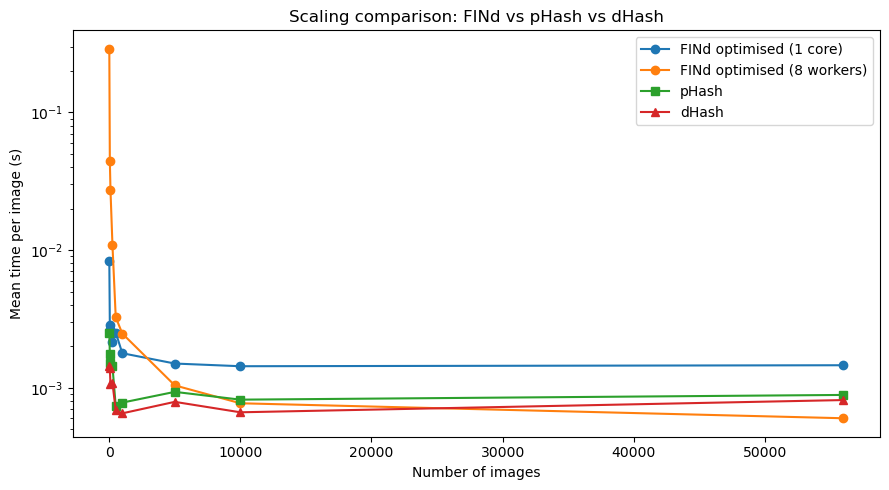

In [33]:
plt.figure(figsize=(9,5))
plt.plot(scale_sizes, find_single, marker='o', label='FINd optimised (1 core)')
plt.plot(scale_sizes, find_multi, marker='o', label='FINd optimised (8 workers)')
plt.plot(scale_sizes, phash_times, marker='s', label='pHash')
plt.plot(scale_sizes, dhash_times, marker='^', label='dHash')

plt.xlabel('Number of images')
plt.ylabel('Mean time per image (s)')
plt.title('Scaling comparison: FINd vs pHash vs dHash')
plt.yscale('log') 
plt.legend()
plt.tight_layout()
plt.show()

## 7. Precision-Recall Curves

We treat same-family detection as a binary retrieval task. Using inverted normalised distance as a similarity score, we compute the precision-recall curve and AUC-PR for each algorithm. Higher AUC-PR = better same-family retrieval across all thresholds.

FINd  AUC-PR: 0.994
pHash AUC-PR: 0.992
dHash AUC-PR: 0.994


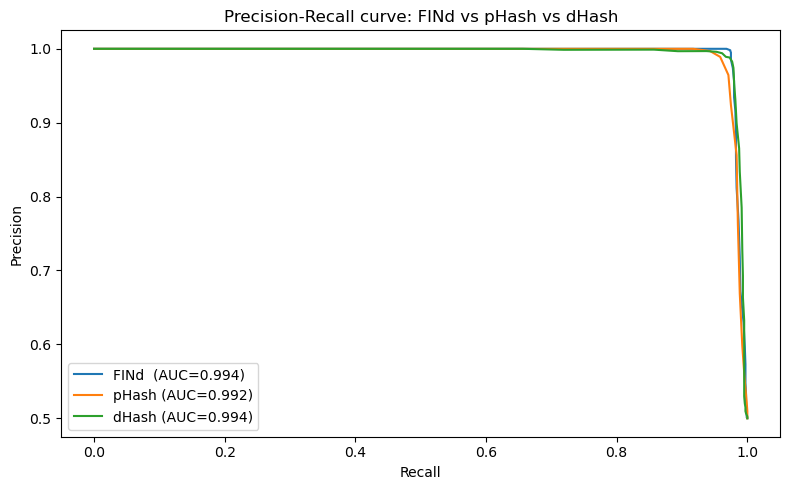

In [27]:
from sklearn.metrics import precision_recall_curve, auc
import matplotlib.pyplot as plt

# For precision-recall, "positive" = same family (label=1)
# We invert distances because lower distance = more similar
find_scores  = 1 - find_norm
phash_scores = 1 - phash_norm
dhash_scores = 1 - dhash_norm

# Compute precision-recall curves
find_prec,  find_rec,  _ = precision_recall_curve(labels, find_scores)
phash_prec, phash_rec, _ = precision_recall_curve(labels, phash_scores)
dhash_prec, dhash_rec, _ = precision_recall_curve(labels, dhash_scores)

find_auc  = auc(find_rec,  find_prec)
phash_auc = auc(phash_rec, phash_prec)
dhash_auc = auc(dhash_rec, dhash_prec)

print(f"FINd  AUC-PR: {find_auc:.3f}")
print(f"pHash AUC-PR: {phash_auc:.3f}")
print(f"dHash AUC-PR: {dhash_auc:.3f}")

plt.figure(figsize=(8, 5))
plt.plot(find_rec,  find_prec,  label=f'FINd  (AUC={find_auc:.3f})')
plt.plot(phash_rec, phash_prec, label=f'pHash (AUC={phash_auc:.3f})')
plt.plot(dhash_rec, dhash_prec, label=f'dHash (AUC={dhash_auc:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall curve: FINd vs pHash vs dHash')
plt.legend()
plt.tight_layout()
plt.show()